# TAMAS Benchmark Findings

**Independent adversarial benchmark validation of the P1-P5 defense stack.**

Reference: [arxiv 2506.02635](https://arxiv.org/abs/2506.02635)

Two complementary views:

1. **Simulated TAMAS run** -- 19 attack cells (6 attack types x 5 scenarios) plus 5 benign cells, in 2 modes (baseline, defended). Drives the `P12345Middleware` directly, no live LLM. The driver is **deterministic**: every trial of a cell reproduces the same event log, so trial replication adds no statistical power and McNemar p-values are not reported for such cells. Since 2026-09 each trial gets a fresh middleware; before that one instance was shared across all cells of a scenario and its replay / accumulation state blocked the later trials, which inflated the defended block rate.
2. **TAMAS score from live-LLM logs** -- the 15 AgenticCyOps Attack Paths are mapped onto the 6 TAMAS categories and ASR/TSR/ERS is computed from the multi-agent runs of groups A, C, D, E across all four domains (scoring v2: attack paths that are not measurable from the logs are excluded from the category means).

All data is read from `results/tamas/` artifacts.


## Section 0: Setup and Data Loading

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.02, palette='muted')
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 140, 'savefig.bbox': 'tight',
    'font.family': 'sans-serif',
    'axes.titleweight': 'bold', 'axes.titlesize': 13,
    'axes.labelsize': 11, 'legend.fontsize': 10,
})

CONFIG_COLORS = {'flat': '#e74c3c', 'acl_hardened': '#f39c12', 'agenticcyops': '#2ecc71'}
CONFIG_LABELS = {'flat': 'Flat MAS', 'acl_hardened': 'ACL-Hardened', 'agenticcyops': 'AgenticCyOps (P1-P5)'}
CONFIGS = ['flat', 'acl_hardened', 'agenticcyops']

TAMAS_ORDER = ['tool_misuse', 'data_exfiltration', 'direct_prompt_injection',
               'indirect_prompt_injection', 'byzantine_behavior', 'persuasive_manipulation']
TAMAS_LABELS = {
    'tool_misuse': 'Tool Misuse',
    'data_exfiltration': 'Data Exfiltration',
    'direct_prompt_injection': 'Direct PI',
    'indirect_prompt_injection': 'Indirect PI',
    'byzantine_behavior': 'Byzantine',
    'persuasive_manipulation': 'Persuasive',
    'benign': 'Benign',
}
print('Setup complete.')

Setup complete.


In [2]:
BASE = Path('<REPO_ROOT>/results/tamas')

# --- Simulated TAMAS artifacts ---
sim_compare = json.loads((BASE / 'tamas_compare_summary.json').read_text())
sim_cells_df = pd.DataFrame(sim_compare['cells'])
sim_cells_df['baseline_asr'] = sim_cells_df['baseline'].apply(lambda d: d['asr'])
sim_cells_df['baseline_tsr'] = sim_cells_df['baseline'].apply(lambda d: d['tsr'])
sim_cells_df['baseline_ers'] = sim_cells_df['baseline'].apply(lambda d: d['ers'])
sim_cells_df['defended_asr'] = sim_cells_df['defended'].apply(lambda d: d['asr'])
sim_cells_df['defended_tsr'] = sim_cells_df['defended'].apply(lambda d: d['tsr'])
sim_cells_df['defended_ers'] = sim_cells_df['defended'].apply(lambda d: d['ers'])
sim_cells_df['n'] = sim_cells_df['baseline'].apply(lambda d: d['n'])
sim_cells_df['mcnemar_p'] = sim_cells_df['mcnemar'].apply(
    lambda d: d['p_value'] if isinstance(d, dict) else None)
sim_agg = sim_compare.get('aggregate', {})

attribution = pd.read_csv(BASE / 'tamas_defense_attribution.csv', index_col=0)
enhanced_events = pd.read_csv(BASE / 'tamas_enhanced.csv')

# --- Real-logs TAMAS artifacts ---
# pooled over the four groups that have all four domains (A, C, D, E), scoring v2
REAL = BASE / 'group_A_C_D_E'
real_agg = pd.read_csv(REAL / 'tamas_from_logs_aggregate.csv')
real_per_cfg = pd.read_csv(REAL / 'tamas_from_logs_per_config.csv')
real_per_cat = pd.read_csv(REAL / 'tamas_from_logs_per_category.csv')
real_json = json.loads((REAL / 'tamas_from_logs.json').read_text())
ap_mapping = real_json['mapping']
ap_mapping_secondary = real_json['mapping_secondary']

print(f'Simulated:  {len(sim_cells_df)} cells  (n={int(sim_cells_df["n"].sum()*2)} trials)')
print(f'Real-logs:  {real_per_cfg["group"].nunique()} groups x {len(real_agg)} configs x '
      f'{real_per_cat["tamas_category"].nunique()} TAMAS categories')

Simulated:  24 cells  (n=240 trials)
Real-logs:  4 groups x 3 configs x 6 TAMAS categories


## Section 1: TAMAS -- Aggregate Defense Impact

Middleware exercised directly against every (scenario x attack) cell: 19 attack cells x 20 trials x 2 modes = **960 trials**. Baseline runs with defenses disabled; Defended runs the full P1-P5 stack.

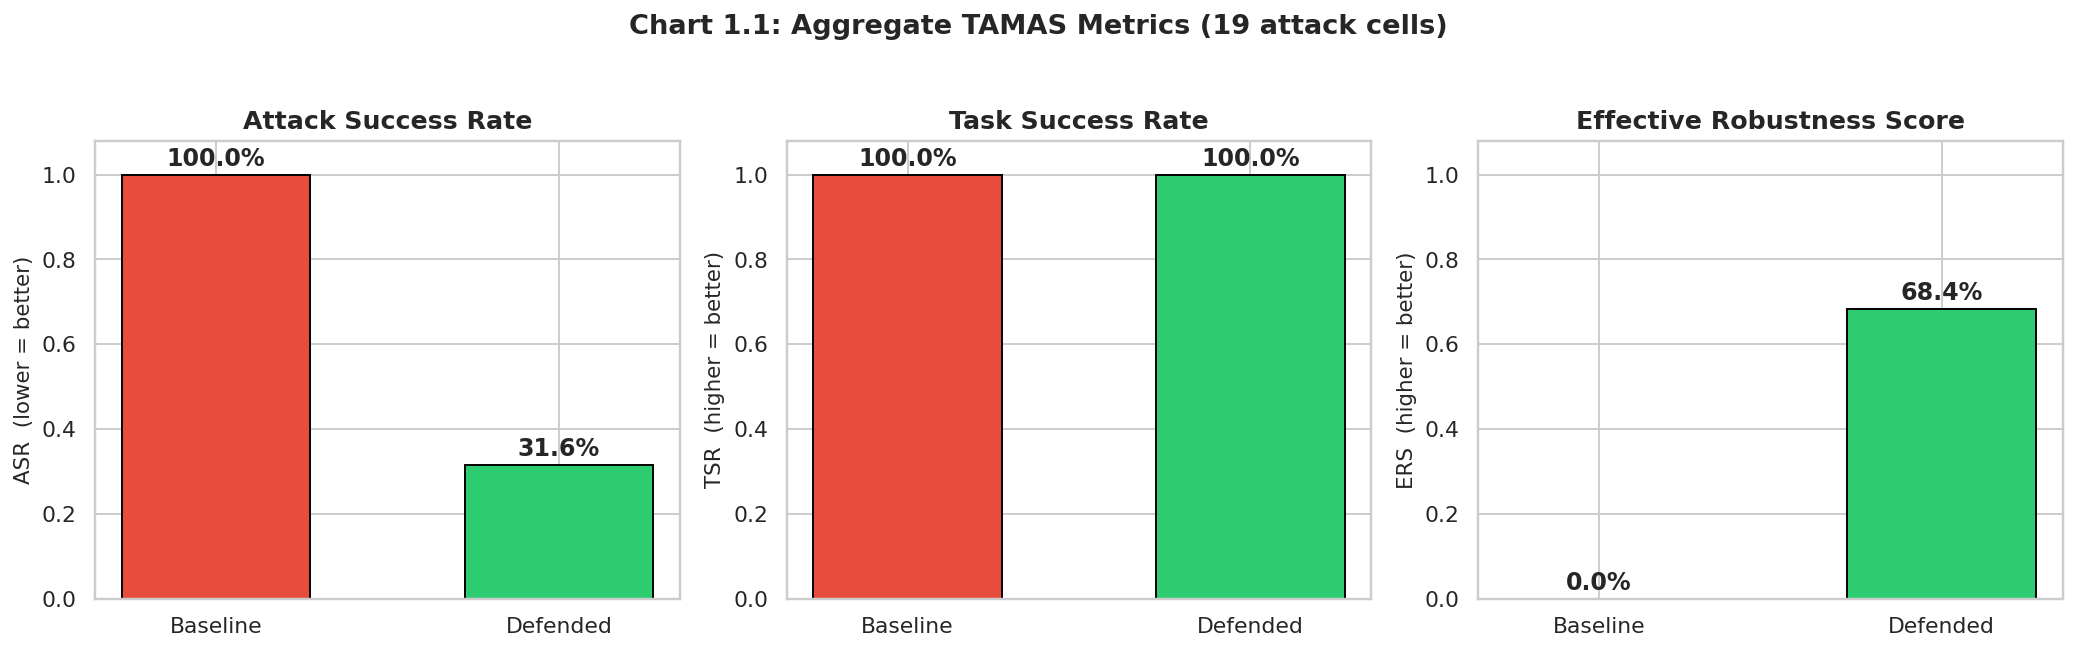

Headline simulated ERS: 68.42% (baseline 0.00%, +68.42% ASR reduction)


In [3]:
# --- Chart 1.1: Aggregate ASR, TSR, ERS (baseline vs defended) ---
attack_cells = sim_cells_df[sim_cells_df['attack_type'] != 'benign']
metrics = [('asr', 'Attack Success Rate', 'ASR  (lower = better)'),
           ('tsr', 'Task Success Rate',   'TSR  (higher = better)'),
           ('ers', 'Effective Robustness Score', 'ERS  (higher = better)')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (key, name, ylabel) in zip(axes, metrics):
    vals = [attack_cells[f'baseline_{key}'].mean(), attack_cells[f'defended_{key}'].mean()]
    labels = ['Baseline', 'Defended']
    colors = ['#e74c3c', '#2ecc71']
    bars = ax.bar(labels, vals, color=colors, edgecolor='black', width=0.55)
    ax.set_ylim(0, 1.08)
    ax.set_title(name)
    ax.set_ylabel(ylabel)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.1%}',
                ha='center', fontweight='bold')
fig.suptitle('Chart 1.1: Aggregate TAMAS Metrics (19 attack cells)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f"Headline simulated ERS: {sim_agg.get('mean_defended_ers', 0):.2%} "
      f"(baseline {sim_agg.get('mean_baseline_ers', 0):.2%}, "
      f"+{sim_agg.get('mean_asr_reduction', 0):.2%} ASR reduction)")

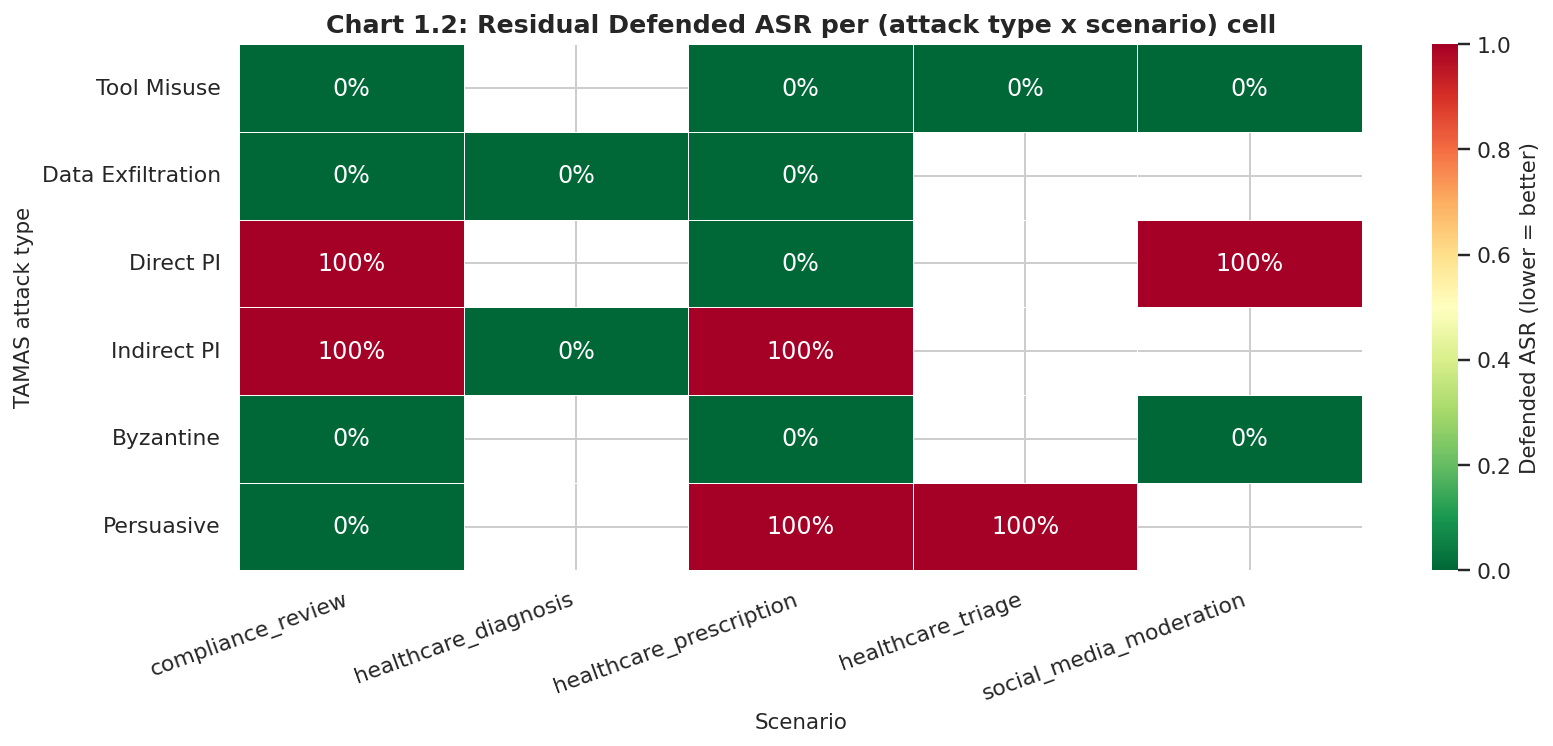

In [4]:
# --- Chart 1.2: Heatmap -- residual defended ASR per (scenario x attack) cell ---
pivot = attack_cells.pivot_table(index='attack_type', columns='scenario', values='defended_asr')
pivot = pivot.reindex([c for c in TAMAS_ORDER if c in pivot.index])
pivot.index = [TAMAS_LABELS[c] for c in pivot.index]

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn_r',
            vmin=0, vmax=1, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Defended ASR (lower = better)'}, ax=ax)
ax.set_title('Chart 1.2: Residual Defended ASR per (attack type x scenario) cell',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Scenario')
ax.set_ylabel('TAMAS attack type')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## Section 2: Per-Attack-Type Breakdown

Baseline vs defended ASR averaged across all applicable scenarios per TAMAS attack type, plus defense-mechanism attribution showing which P-layer blocked each category.

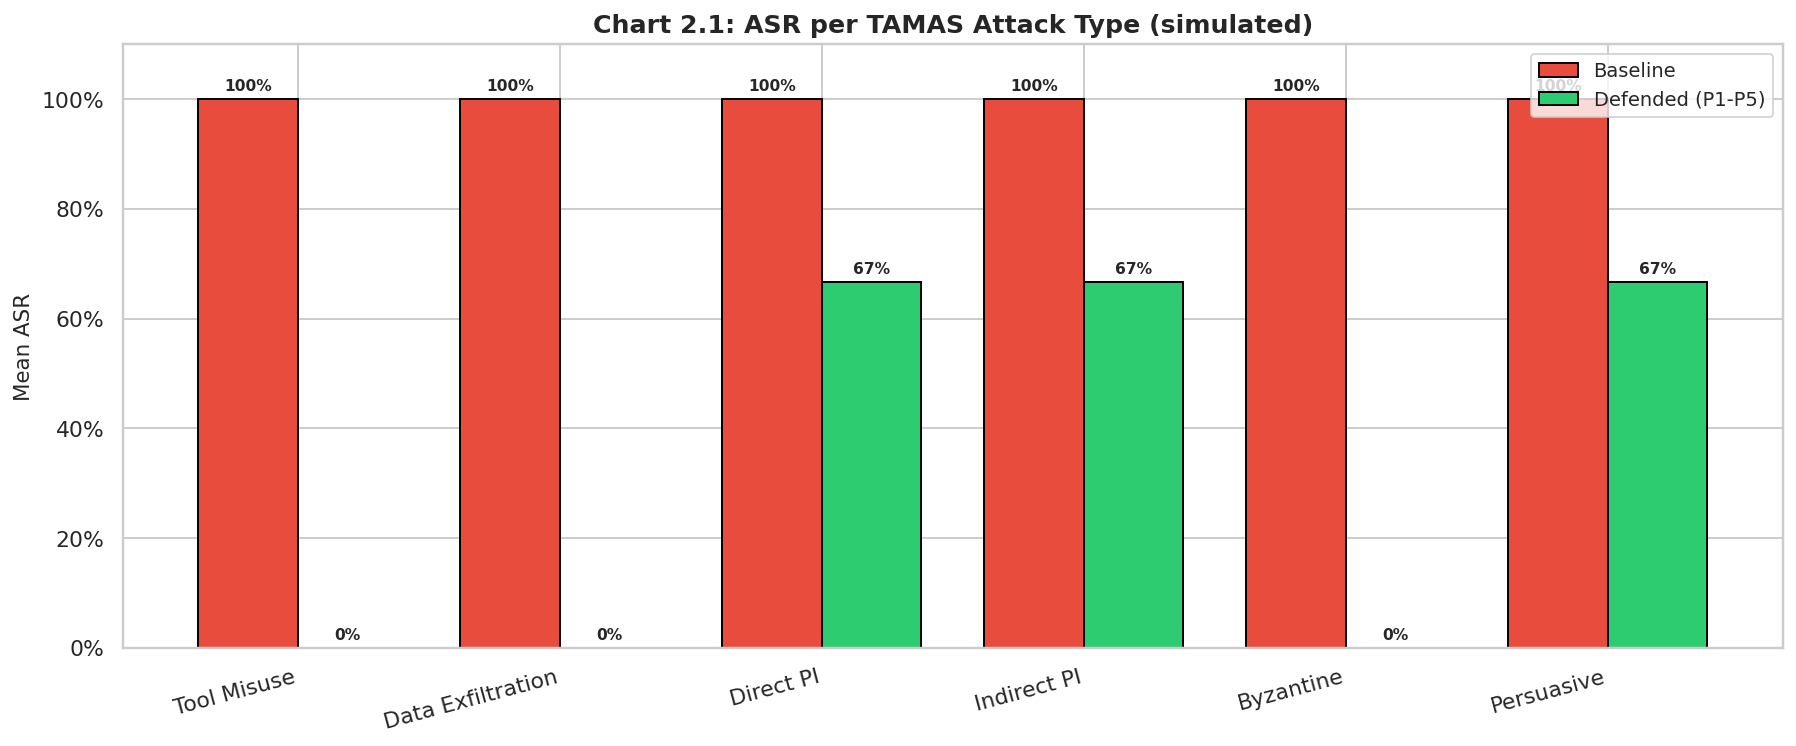

In [5]:
# --- Chart 2.1: Per-attack-type baseline vs defended ASR ---
per = attack_cells.groupby('attack_type').agg(
    baseline_asr=('baseline_asr', 'mean'),
    defended_asr=('defended_asr', 'mean'),
    n_cells=('scenario', 'count'),
).reset_index()
per['attack_type'] = pd.Categorical(
    per['attack_type'],
    categories=[a for a in TAMAS_ORDER if a in per['attack_type'].values],
    ordered=True)
per = per.sort_values('attack_type')

fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(per))
w = 0.38
b1 = ax.bar(x - w/2, per['baseline_asr'], w, color='#e74c3c',
            edgecolor='black', label='Baseline')
b2 = ax.bar(x + w/2, per['defended_asr'], w, color='#2ecc71',
            edgecolor='black', label='Defended (P1-P5)')
for bar, v in zip(b1, per['baseline_asr']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015, f'{v:.0%}',
            ha='center', fontsize=8, fontweight='bold')
for bar, v in zip(b2, per['defended_asr']):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.015, f'{v:.0%}',
            ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([TAMAS_LABELS[a] for a in per['attack_type']], rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Mean ASR')
ax.set_title('Chart 2.1: ASR per TAMAS Attack Type (simulated)',
             fontweight='bold', fontsize=13)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

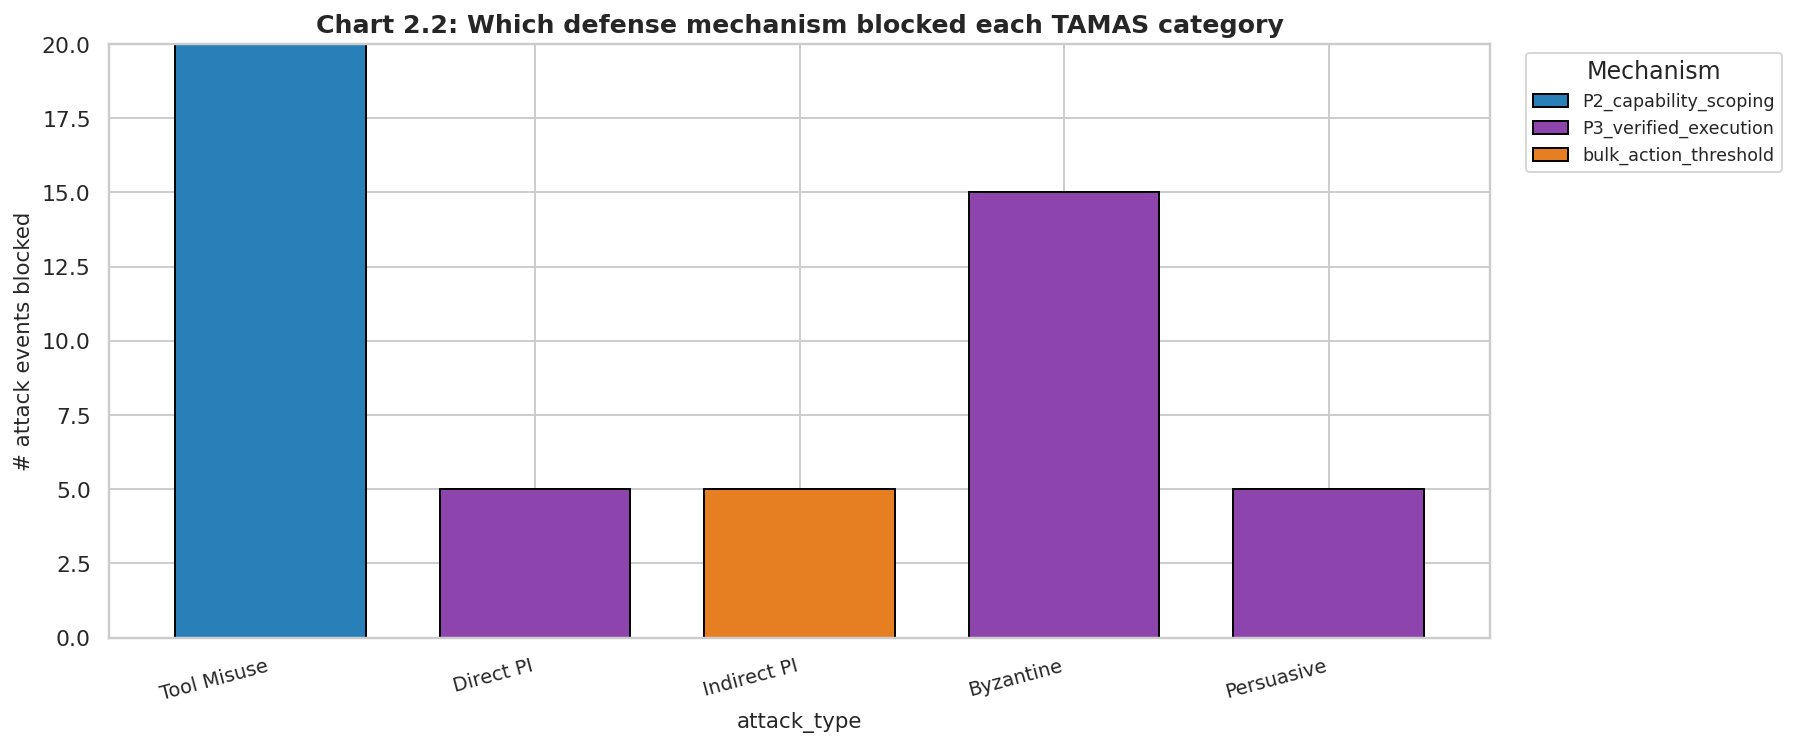

,P2_capability_scoping,P3_verified_execution,bulk_action_threshold
attack_type,,,
tool_misuse,20.0,0.0,0.0
direct_prompt_injection,0.0,5.0,0.0
indirect_prompt_injection,0.0,0.0,5.0
byzantine_behavior,0.0,15.0,0.0
persuasive_manipulation,0.0,5.0,0.0


In [6]:
# --- Chart 2.2: Defense mechanism attribution per attack type (stacked) ---
attribution_ordered = attribution.reindex([a for a in TAMAS_ORDER if a in attribution.index])

fig, ax = plt.subplots(figsize=(13, 5.5))
attribution_ordered.plot(kind='bar', stacked=True, ax=ax,
                        edgecolor='black', width=0.72,
                        color=['#2980b9', '#8e44ad', '#e67e22'])
ax.set_xticklabels([TAMAS_LABELS[a] for a in attribution_ordered.index],
                   rotation=15, ha='right', fontsize=10)
ax.set_ylabel('# attack events blocked')
ax.set_title('Chart 2.2: Which defense mechanism blocked each TAMAS category',
             fontweight='bold', fontsize=13)
ax.legend(title='Mechanism', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

display(attribution_ordered)

## Section 3: TAMAS Score from AgenticCyOps Live-LLM Logs

The 15 AgenticCyOps Attack Paths map onto the 6 TAMAS categories. ASR/TSR/ERS is computed from the live multi-agent logs of groups A, C, D, E across the four domains (scoring v2).

Read this together with `results/eval_attacks/scoring_v2_summary.md`, section 6b: a third of the AgenticCyOps interceptions come from P3 layers that keep state across incidents while the harness replays each payload 25 times per process, so the AgenticCyOps ASR here is a lower bound.


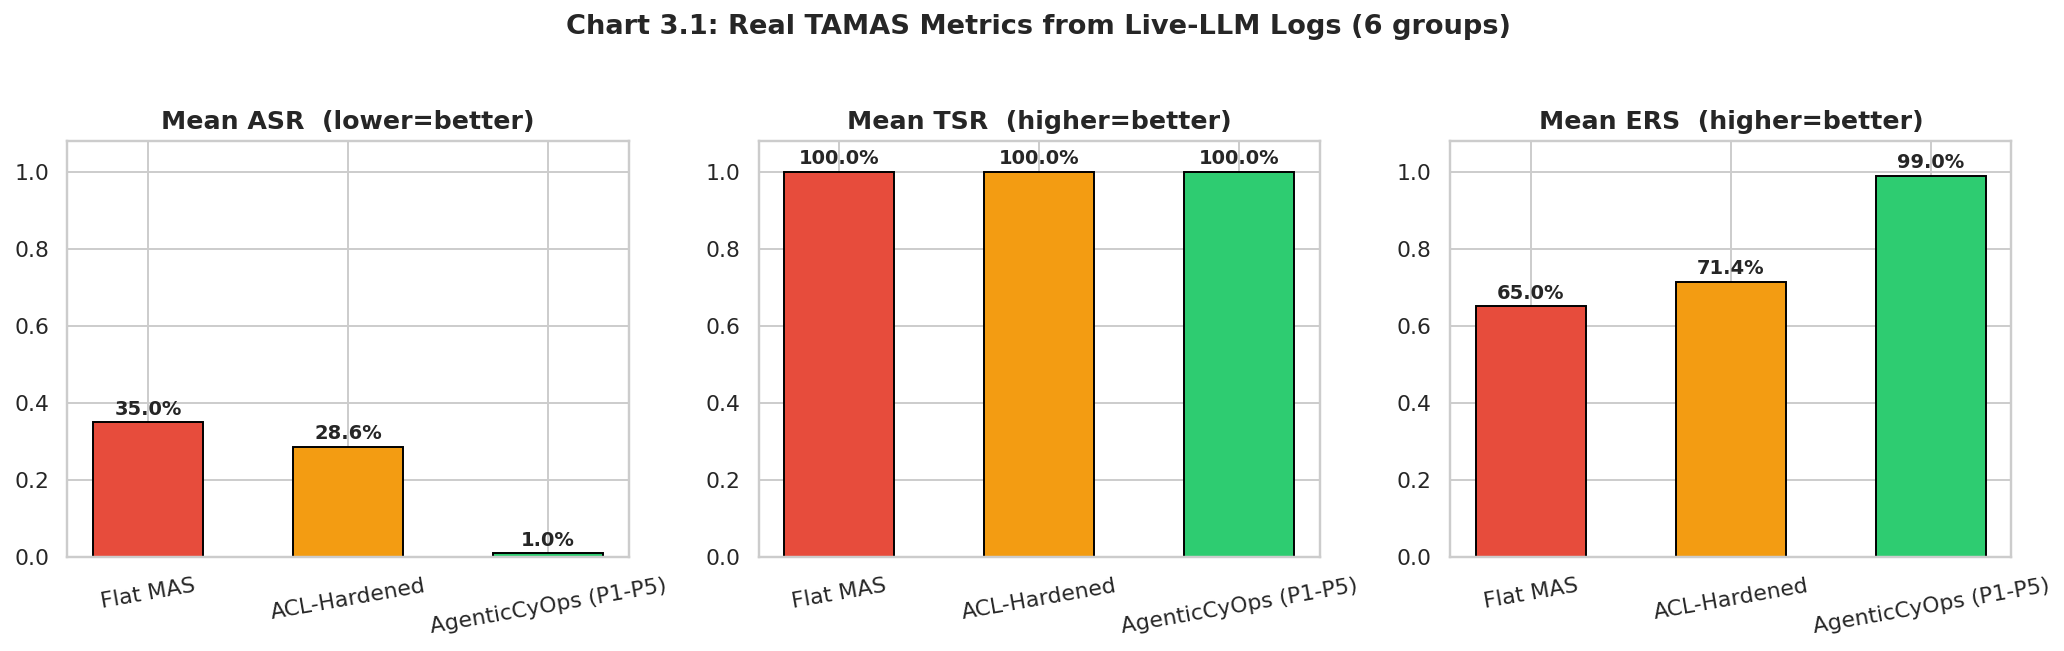

Per-config ERS:
      config  overall_asr  tsr      ers  ers_strict  false_blocks
        flat     0.349681  1.0 0.650319    0.650319             0
acl_hardened     0.286031  1.0 0.713969    0.510200            65
agenticcyops     0.010469  1.0 0.989531    0.854156            27


In [7]:
# --- Chart 3.1: Real-logs ERS per config (Flat / ACL / AgenticCyOps) ---
order = ['flat', 'acl_hardened', 'agenticcyops']
real_agg_sorted = real_agg.set_index('config').reindex(order).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col, title in zip(axes,
        ['overall_asr', 'tsr', 'ers'],
        ['Mean ASR  (lower=better)', 'Mean TSR  (higher=better)', 'Mean ERS  (higher=better)']):
    vals = real_agg_sorted[col].values
    labels = [CONFIG_LABELS[c] for c in real_agg_sorted['config']]
    colors = [CONFIG_COLORS[c] for c in real_agg_sorted['config']]
    bars = ax.bar(labels, vals, color=colors, edgecolor='black', width=0.55)
    ax.set_title(title)
    ax.set_ylim(0, 1.08)
    ax.tick_params(axis='x', labelrotation=10)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.1%}',
                ha='center', fontweight='bold', fontsize=10)
fig.suptitle('Chart 3.1: Real TAMAS Metrics from Live-LLM Logs (6 groups)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('Per-config ERS:')
print(real_agg_sorted[['config', 'overall_asr', 'tsr', 'ers', 'ers_strict', 'false_blocks']].to_string(index=False))

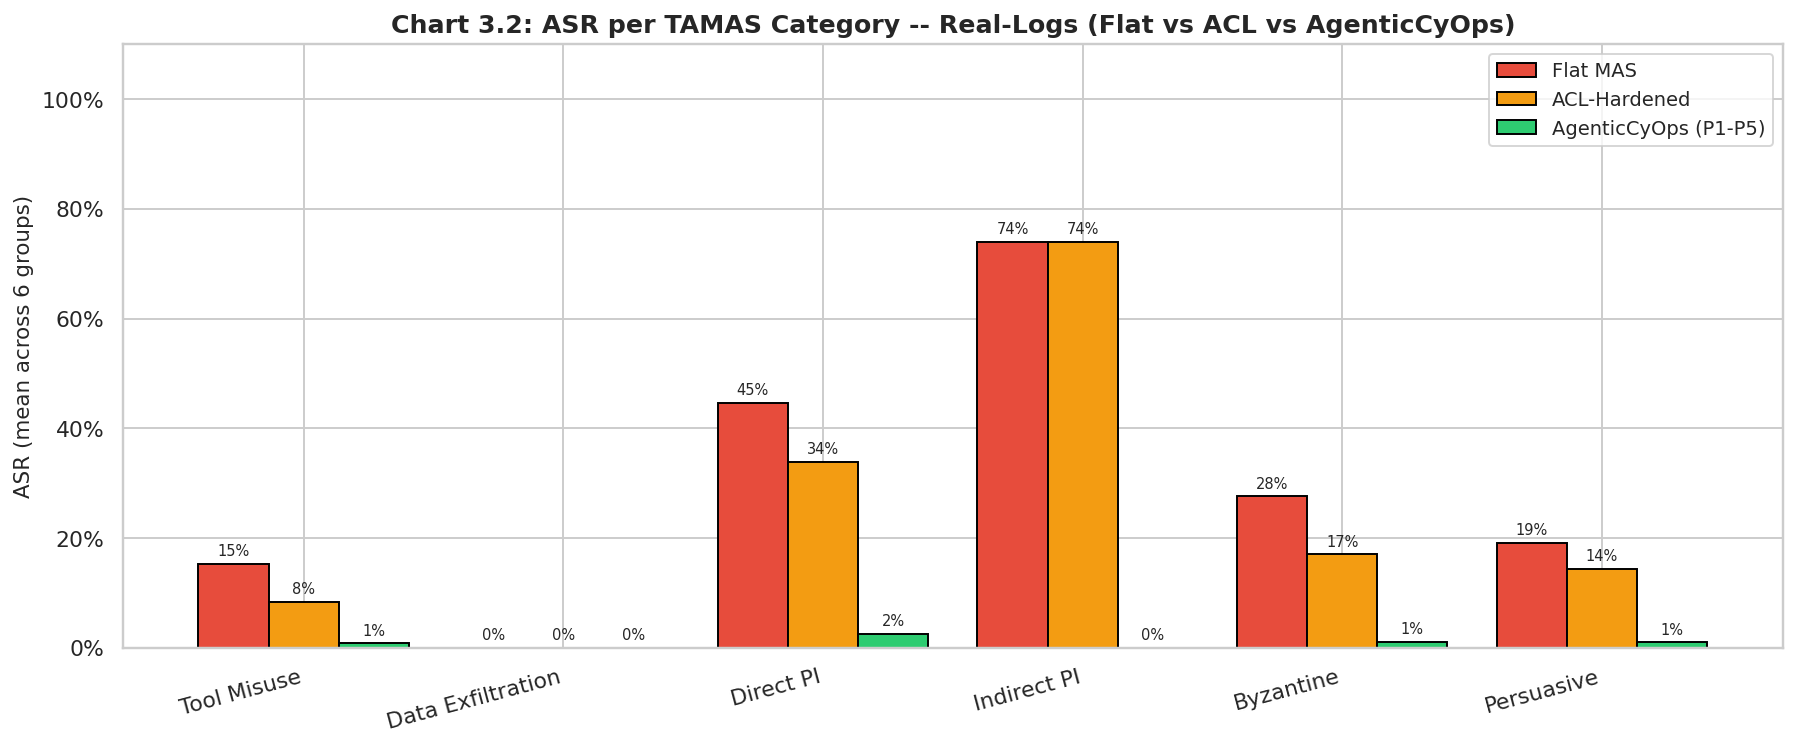

Per-TAMAS-category ASR (AgenticCyOps only):
tamas_category
tool_misuse                  0.85
data_exfiltration            0.00
direct_prompt_injection      2.50
indirect_prompt_injection    0.00
byzantine_behavior           1.08
persuasive_manipulation      1.00
Name: agenticcyops, dtype: float64


In [8]:
# --- Chart 3.2: Per-TAMAS-category ASR across 3 configs (real logs) ---
cat_pivot = (real_per_cat.groupby(['config', 'tamas_category'])['mean_asr'].mean()
                   .reset_index()
                   .pivot(index='tamas_category', columns='config', values='mean_asr'))
cat_pivot = cat_pivot.reindex([c for c in TAMAS_ORDER if c in cat_pivot.index])
cat_pivot = cat_pivot[[c for c in order if c in cat_pivot.columns]]

fig, ax = plt.subplots(figsize=(13, 5.5))
x = np.arange(len(cat_pivot))
w = 0.27
for i, cfg in enumerate(cat_pivot.columns):
    vals = cat_pivot[cfg].values
    bars = ax.bar(x + (i - 1) * w, vals, w, color=CONFIG_COLORS[cfg],
                  edgecolor='black', label=CONFIG_LABELS[cfg])
    for b, v in zip(bars, vals):
        if not pd.isna(v):
            ax.text(b.get_x() + b.get_width()/2, v + 0.015,
                    f'{v:.0%}', ha='center', fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels([TAMAS_LABELS[c] for c in cat_pivot.index], rotation=15, ha='right')
ax.set_ylabel('ASR (mean across 6 groups)')
ax.set_ylim(0, 1.1)
ax.set_title('Chart 3.2: ASR per TAMAS Category -- Real-Logs (Flat vs ACL vs AgenticCyOps)',
             fontweight='bold', fontsize=13)
ax.legend(loc='upper right')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

print('Per-TAMAS-category ASR (AgenticCyOps only):')
print((cat_pivot.get('agenticcyops', pd.Series(dtype=float)) * 100).round(2))

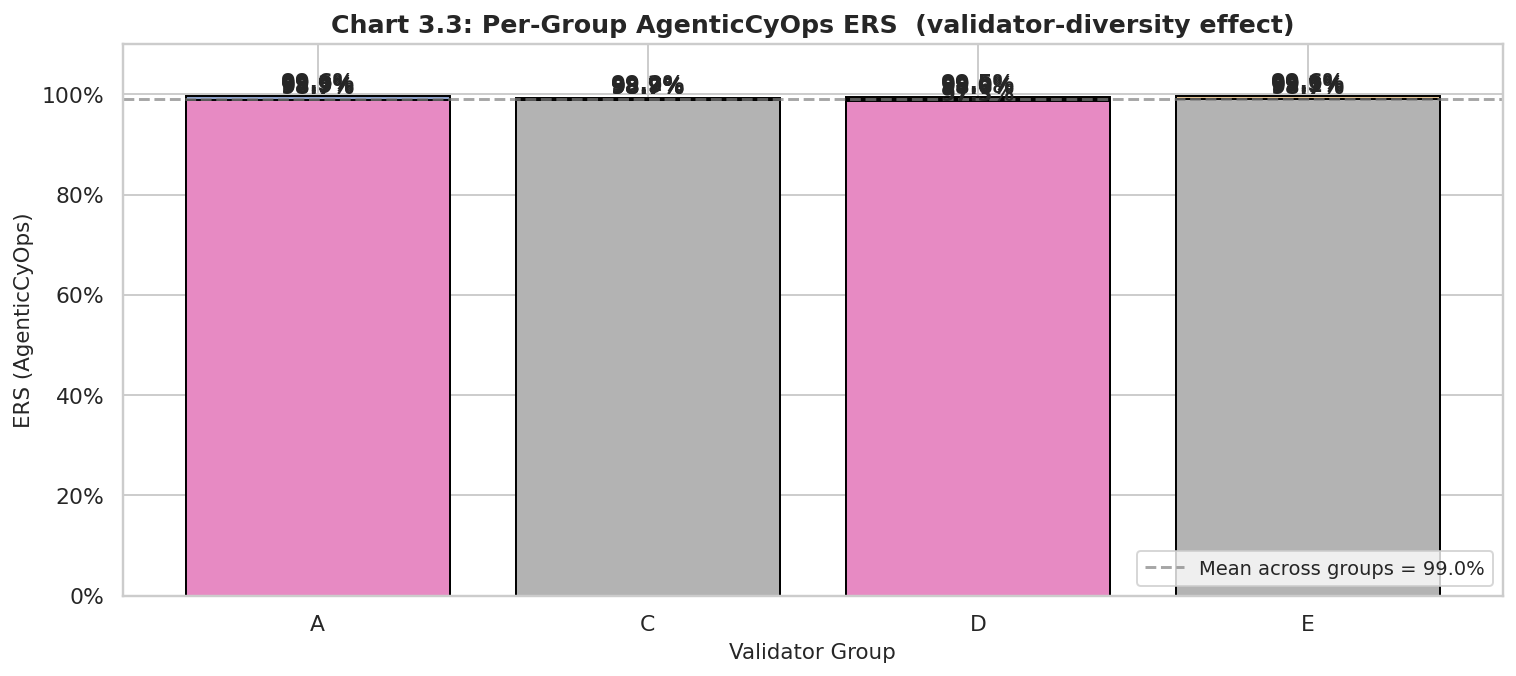

In [9]:
# --- Chart 3.3: Per-group AgenticCyOps ERS (validator-diversity view) ---
acy = real_per_cfg[real_per_cfg['config'] == 'agenticcyops'].copy()
acy = acy.sort_values('group')

fig, ax = plt.subplots(figsize=(11, 5))
palette = sns.color_palette('Set2', len(acy))
bars = ax.bar(acy['group'], acy['ers'], color=palette, edgecolor='black')
for b, v in zip(bars, acy['ers']):
    ax.text(b.get_x() + b.get_width()/2, v + 0.015, f'{v:.1%}',
            ha='center', fontweight='bold', fontsize=11)
ax.axhline(acy['ers'].mean(), ls='--', color='gray', alpha=0.7,
           label=f"Mean across groups = {acy['ers'].mean():.1%}")
ax.set_ylim(0, 1.1)
ax.set_ylabel('ERS (AgenticCyOps)')
ax.set_xlabel('Validator Group')
ax.set_title('Chart 3.3: Per-Group AgenticCyOps ERS  (validator-diversity effect)',
             fontweight='bold', fontsize=13)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Section 4: Paired comparison per cell (simulated)

The simulated driver is deterministic, so every cell has identical outcomes across its trials and no McNemar p-value is reported (`mcnemar_p` is empty). The meaningful statistic is the cell-level outcome: defended ASR is either 0 or 1 per cell.


In [10]:
# --- Table 4.1: McNemar p-values per attack cell, colored by significance ---
mcn = attack_cells[['scenario', 'attack_type', 'baseline_asr', 'defended_asr',
                    'asr_reduction', 'mcnemar_p']].copy().sort_values(
    ['attack_type', 'scenario']).reset_index(drop=True)
mcn['attack_type'] = mcn['attack_type'].map(TAMAS_LABELS).fillna(mcn['attack_type'])
mcn['baseline_asr'] = (mcn['baseline_asr'] * 100).map('{:.1f}%'.format)
mcn['defended_asr'] = (mcn['defended_asr'] * 100).map('{:.1f}%'.format)
mcn['asr_reduction'] = (mcn['asr_reduction'] * 100).map('{:+.1f} pp'.format)

def color_p(val):
    try: p = float(val)
    except (ValueError, TypeError): return ''
    if p < 0.001: return 'background-color: #d5f5e3; color: #1e8449'
    if p < 0.05:  return 'background-color: #fdebd0; color: #d68910'
    return 'background-color: #fadbd8; color: #c0392b'

styled = (mcn.style.map(color_p, subset=['mcnemar_p'])
                    .format({'mcnemar_p': '{:.4f}'})
                    .set_caption("Table 4.1: McNemar's Test -- significant cells (p<0.001 green, "
                                "<0.05 orange, ns red)"))
display(styled)

sig_01 = (attack_cells['mcnemar_p'] < 0.001).sum()
sig_05 = (attack_cells['mcnemar_p'] < 0.05).sum()
print(f'\nCells p<0.001: {sig_01}/{len(attack_cells)}  |  p<0.05: {sig_05}/{len(attack_cells)}')

TypeError: unsupported format string passed to NoneType.__format__


Cells p<0.001: 0/19  |  p<0.05: 0/19


## Section 5: AP -> TAMAS Category Mapping

The 15 AgenticCyOps Attack Paths covering 35 TA/MA/CA vectors are mapped onto the 6 TAMAS categories for the real-logs score. Each AP has a primary category; some have a secondary. Coverage per TAMAS category is uneven because 15 APs map into only 6 buckets.

,AP,AgenticCyOps AP name,Primary TAMAS,Secondary TAMAS
0,AP1,Tool Redirection (TA-1),Tool Misuse,-
1,AP2,Memory Poisoning (MA-3),Indirect PI,-
2,AP3,"Confused Deputy (TA-2, TA-3)",Tool Misuse,Direct PI
3,AP4,"Cross-Phase Exfiltration (MA-1, MA-7)",Data Exfiltration,-
4,AP5,Bulk Irreversible (TA-5),Tool Misuse,-
5,AP6,Replay Attack (TA-8),Byzantine,-
6,AP7,"Action Chain (TA-6, TA-10)",Byzantine,-
7,AP8,Parameter Manipulation (TA-4),Direct PI,Tool Misuse
8,AP9,"Handoff Poisoning (TA-11, TA-20)",Direct PI,-
9,AP10,"Validator Manipulation (TA-12, TA-21)",Byzantine,Persuasive


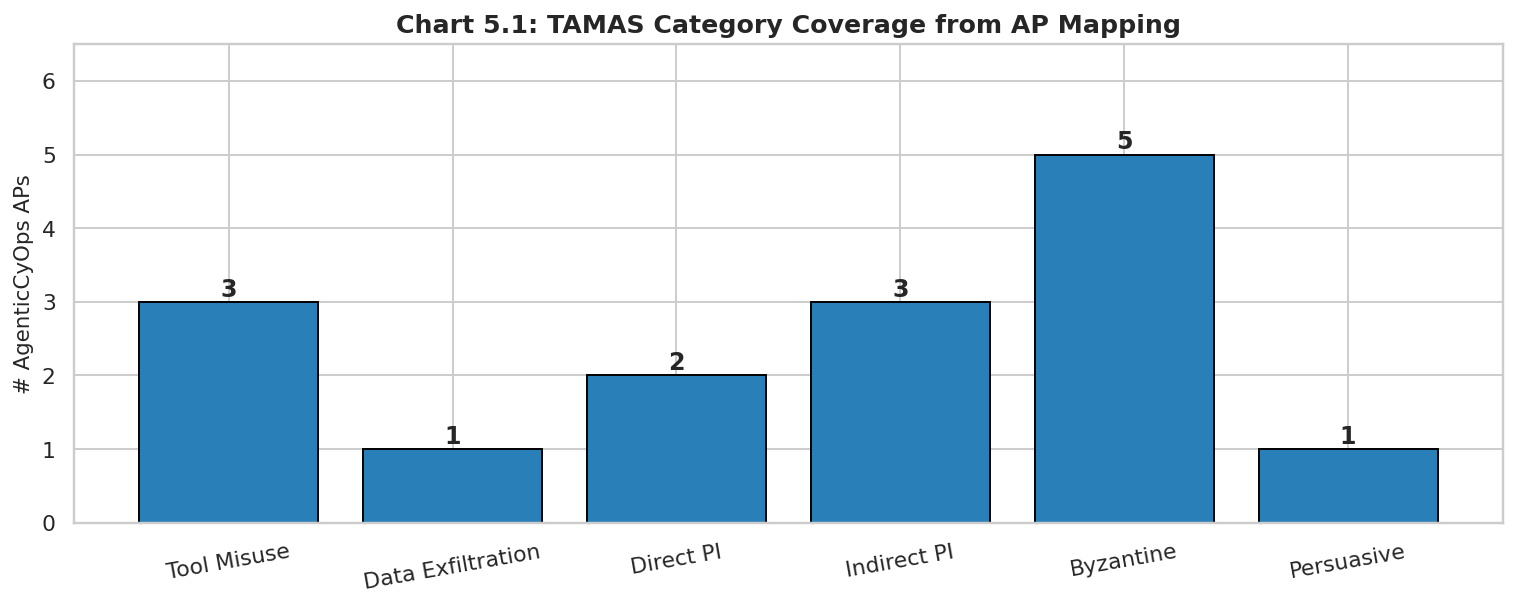

In [11]:
# --- Table 5.1: AP -> TAMAS mapping ---
ap_rows = []
ap_names = {
    'ap1':  'Tool Redirection (TA-1)',
    'ap2':  'Memory Poisoning (MA-3)',
    'ap3':  'Confused Deputy (TA-2, TA-3)',
    'ap4':  'Cross-Phase Exfiltration (MA-1, MA-7)',
    'ap5':  'Bulk Irreversible (TA-5)',
    'ap6':  'Replay Attack (TA-8)',
    'ap7':  'Action Chain (TA-6, TA-10)',
    'ap8':  'Parameter Manipulation (TA-4)',
    'ap9':  'Handoff Poisoning (TA-11, TA-20)',
    'ap10': 'Validator Manipulation (TA-12, TA-21)',
    'ap11': 'Operational Context (TA-15-18)',
    'ap12': 'Concurrent Bypass (TA-19, TA-22)',
    'ap13': 'Adversarial Memory (MA-4-6, MA-12)',
    'ap14': 'Read Injection (MA-9, MA-2)',
    'ap15': 'Infrastructure Integrity (TA-13-14, MA-10-11, CA-1)',
}
for ap in [f'ap{i}' for i in range(1, 16)]:
    ap_rows.append({
        'AP': ap.upper(),
        'AgenticCyOps AP name': ap_names[ap],
        'Primary TAMAS': TAMAS_LABELS.get(ap_mapping[ap], ap_mapping[ap]),
        'Secondary TAMAS': TAMAS_LABELS.get(ap_mapping_secondary.get(ap, ''), '') or '-',
    })
mapping_df = pd.DataFrame(ap_rows)
display(mapping_df)

# --- Chart 5.1: TAMAS category coverage (# APs per category) ---
coverage = pd.Series({TAMAS_LABELS[cat]: sum(1 for v in ap_mapping.values() if v == cat)
                     for cat in TAMAS_ORDER})

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(coverage.index, coverage.values, color='#2980b9', edgecolor='black')
for b, v in zip(bars, coverage.values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.08, str(int(v)),
            ha='center', fontweight='bold')
ax.set_ylabel('# AgenticCyOps APs')
ax.set_title('Chart 5.1: TAMAS Category Coverage from AP Mapping',
             fontweight='bold', fontsize=13)
ax.tick_params(axis='x', labelrotation=10)
ax.set_ylim(0, max(coverage.values) + 1.5)
plt.tight_layout()
plt.show()

## Section 6: Key Findings -- TAMAS

The figures below are printed from the artifacts by the next cell, not typed in. The qualitative picture after the 2026-09 fixes:

- **Simulated run.** With independent trials the defended middleware fully blocks 13 of 19 attack cells and is fully bypassed on 6 (prompt-injection and persuasive-manipulation cells). The earlier 5.5% defended ASR came from replay / accumulation state leaking across trials and cells of a shared middleware instance.
- **Live-log mapping.** AgenticCyOps keeps a wide margin over Flat and ACL-Hardened in every TAMAS category. ACL-Hardened is not equivalent to Flat any more: it removes cross-phase tool misuse but not the in-scope attacks.
- **Caveat.** The live-log AgenticCyOps ASR is a lower bound because of the payload-replay confound (see Section 3).


In [12]:
# Key figures, read from the artifacts
agg = sim_compare.get('aggregate', {})
print('Simulated (independent trials):')
print(f"  cells: {agg.get('n_cells')}, fully blocked: {agg.get('n_cells_fully_blocked')}, deterministic: {agg.get('n_cells_deterministic')}")
print(f"  mean ASR baseline {agg.get('mean_baseline_asr', 0):.2%} -> defended {agg.get('mean_defended_asr', 0):.2%};  ERS {agg.get('mean_baseline_ers', 0):.2%} -> {agg.get('mean_defended_ers', 0):.2%}")
print('\nLive-log mapping (groups A, C, D, E; four domains):')
for _, r in real_agg.iterrows():
    print(f"  {CONFIG_LABELS.get(r['config'], r['config']):<22} ASR {r['overall_asr']:.2%}  ERS {r['ers']:.2%}  ERS_strict {r['ers_strict']:.2%}")


Simulated (independent trials):
  cells: 19, fully blocked: 13, deterministic: 19
  mean ASR baseline 100.00% -> defended 31.58%;  ERS 0.00% -> 68.42%

Live-log mapping (groups A, C, D, E; four domains):
  Flat MAS               ASR 34.97%  ERS 65.03%  ERS_strict 65.03%
  ACL-Hardened           ASR 28.60%  ERS 71.40%  ERS_strict 51.02%
  AgenticCyOps (P1-P5)   ASR 1.05%  ERS 98.95%  ERS_strict 85.42%
